In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/ASSIGNMENT/assignment 8/archive (1).zip" -d "/content/"

In [ ]:
import os
print(os.listdir('/content/'))

['.config', 'seg_train', 'seg_pred', 'archive.zip', 'drive', 'seg_test', 'sample_data']


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

Data Understanding and Preprocessing

In [ ]:
train_dir = '/content/seg_train/seg_train/'
test_dir = '/content/seg_test/seg_test/'

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
print("Loading Dataset ")

Loading Dataset 


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3000 files belonging to 6 classes.


In [ ]:
class_names = train_ds.class_names
print("\nDetected Target Classes:", class_names)


Detected Target Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']



Visualizing Sample Images from the Dataset...
Loaded Batch Image Shape: (32, 150, 150, 3) (Batch Size, Height, Width, Channels)


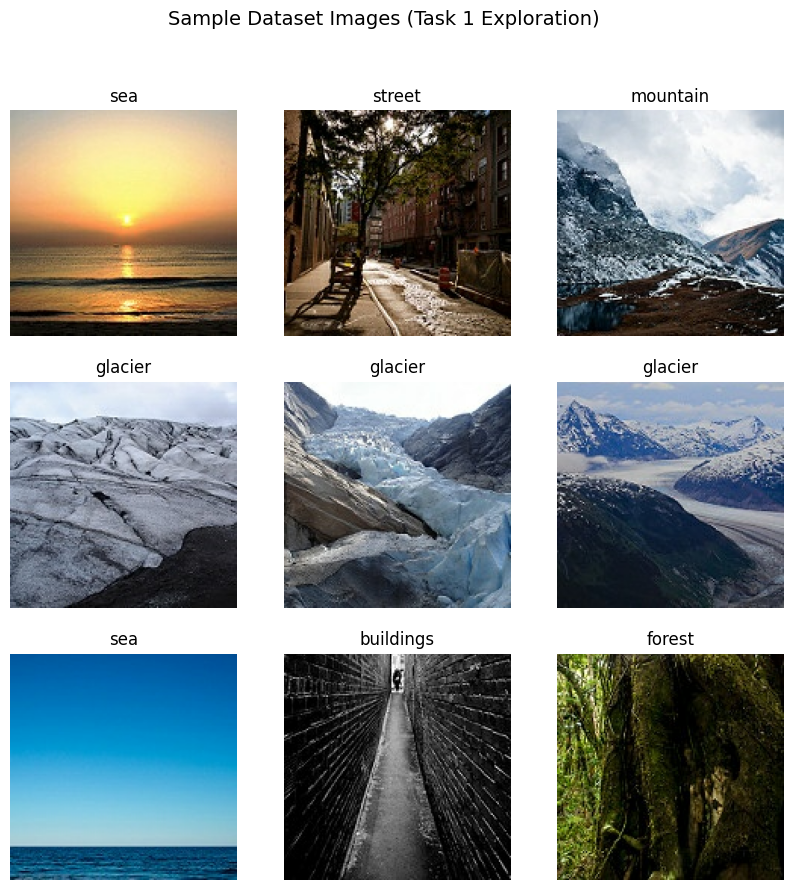

In [ ]:
print("\nVisualizing Sample Images from the Dataset...")
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    print(f"Loaded Batch Image Shape: {images.shape} (Batch Size, Height, Width, Channels)")
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Dataset Images (Task 1 Exploration)", fontsize=14)
plt.show()

In [ ]:
normalization_layer = layers.Rescaling(1./255, name="Pixel_Normalization_Layer")

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
], name="Data_Augmentation_Pipeline")

In [ ]:
print("Preprocessing steps configured successfully:")
print("1. Target Image Dimensions resized to: 150x150 pixels")
print("2. Pixel values normalized to [0, 1] scale.")
print("3. Dataset split successfully into Train (80%), Validation (20%), and Test sets.")
print("4. Augmentation transformations defined (Flip, Rotation, Zoom, Translation).")


Preprocessing steps configured successfully:
1. Target Image Dimensions resized to: 150x150 pixels
2. Pixel values normalized to [0, 1] scale.
3. Dataset split successfully into Train (80%), Validation (20%), and Test sets.
4. Augmentation transformations defined (Flip, Rotation, Zoom, Translation).


CNN Model Development

In [ ]:
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Data_Augmentation_Pipeline      │ ?                      │   0 (unbuilt) │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
monitors = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,

    callbacks=monitors
)

Epoch 1/12
351/351 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.4882 - loss: 1.2858 - val_accuracy: 0.5428 - val_loss: 1.1620
Epoch 2/12
351/351 ━━━━━━━━━━━━━━━━━━━━ 620s 2s/step - accuracy: 0.5867 - loss: 1.0838 - val_accuracy: 0.6572 - val_loss: 0.8985
Epoch 3/12
351/351 ━━━━━━━━━━━━━━━━━━━━ 629s 2s/step - accuracy: 0.6243 - loss: 1.0004 - val_accuracy: 0.6953 - val_loss: 0.8348
Epoch 4/12
351/351 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - accuracy: 0.6530 - loss: 0.9460 - val_accuracy: 0.7349 - val_loss: 0.7302
Epoch 5/12
351/351 ━━━━━━━━━━━━━━━━━━━━ 609s 2s/step - accuracy: 0.6717 - loss: 0.9056 - val_accuracy: 0.7534 - val_loss: 0.6725
Epoch 6/12
351/351 ━━━━━━━━━━━━━━━━━━━━ 611s 2s/step - accuracy: 0.6830 - loss: 0.8819 - val_accuracy: 0.7452 - val_loss: 0.6874
Epoch 7/12
351/351 ━━━━━━━━━━━━━━━━━━━━ 573s 2s/step - accuracy: 0.6889 - loss: 0.8555 - val_accuracy: 0.7096 - val_loss: 0.7498
Epoch 8/12
351/351 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - accuracy: 0.6967 - loss: 0.8409 - val_accu

In [20]:
print("\nPlotting Performance History Curves...")
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(train_acc))


Plotting Performance History Curves...


In [21]:
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

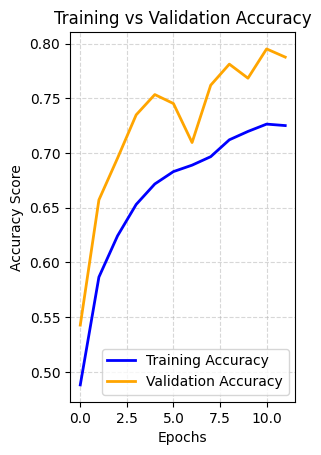

In [22]:
#  Accuracy Progression Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)


In [ ]:
#  Loss Evaluation Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

 Model Ealuation and Interpretation



Evaluate the model

In [25]:
test_dir = "/content/seg_test/seg_test/"
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

ordered_test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3000 files belonging to 6 classes.


In [26]:
true_labels_list = []
sample_images_list = []

for images, labels in ordered_test_ds:
    true_labels_list.extend(labels.numpy())
    sample_images_list.extend(images.numpy())

all_true_labels = np.array(true_labels_list)
all_test_images = np.array(sample_images_list)

print("Predicting test dataset classes...")
preds = model.predict(ordered_test_ds, verbose=1)
all_pred_labels = np.argmax(preds, axis=1)

Predicting test dataset classes...
94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 380ms/step


In [27]:
# Displaying Classification Metrics Table (Accuracy, Precision, Recall, F1)
print("\n...............CLASSIFICATION PERFORMANCE REPORT ....................")
print(classification_report(all_true_labels, all_pred_labels, target_names=class_names))


...............CLASSIFICATION PERFORMANCE REPORT ....................
              precision    recall  f1-score   support

   buildings       0.70      0.77      0.73       437
      forest       0.94      0.92      0.93       474
     glacier       0.76      0.79      0.78       553
    mountain       0.80      0.65      0.72       525
         sea       0.75      0.78      0.76       510
      street       0.78      0.83      0.80       501

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



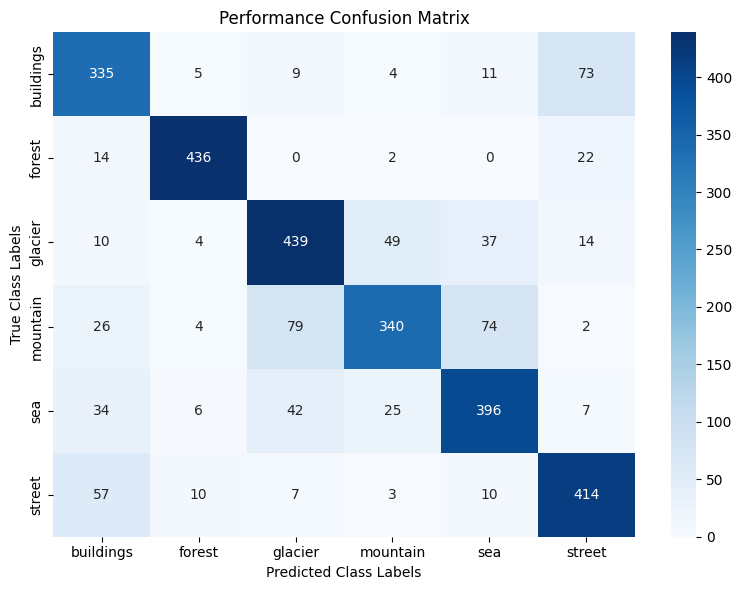

In [28]:
cm = confusion_matrix(all_true_labels, all_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Performance Confusion Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('True Class Labels')
plt.tight_layout()
plt.show()

Visualizing predicted Vs actual label

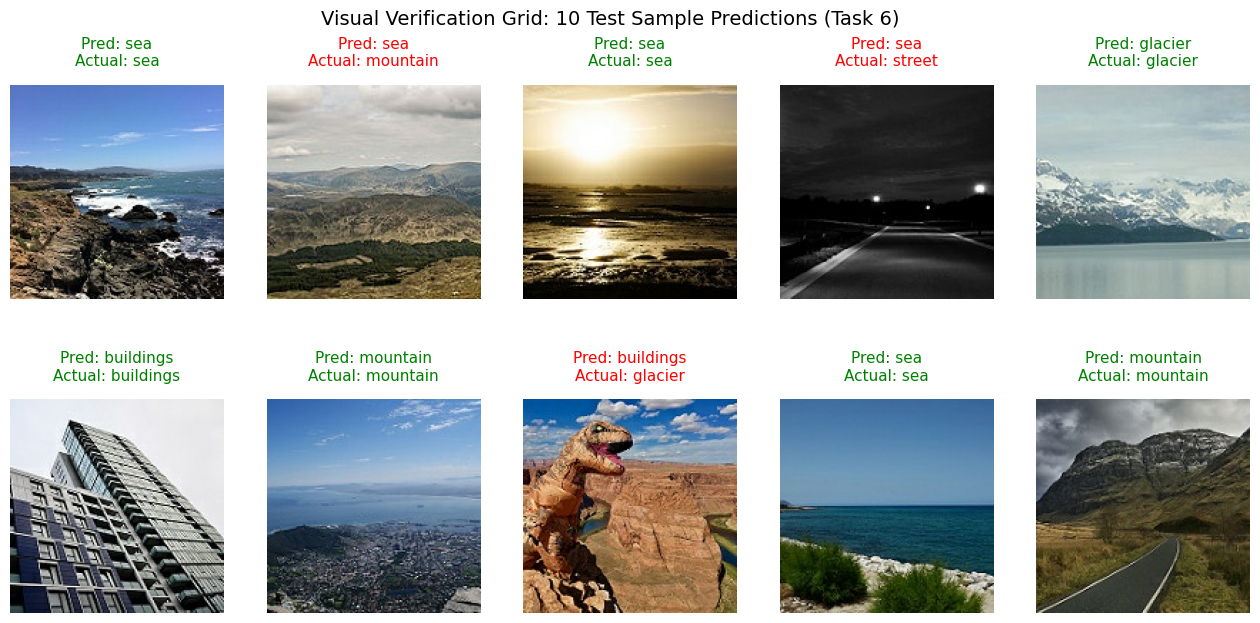

In [29]:

plt.figure(figsize=(16, 7))

random_indices = np.random.choice(len(all_test_images), size=10, replace=False)

for i, idx in enumerate(random_indices):
    img = all_test_images[idx] / 255.0
    true_label = class_names[all_true_labels[idx]]
    pred_label = class_names[all_pred_labels[idx]]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)

    # Green text if correct, Red text if the model made a mistake
    text_color = 'green' if true_label == pred_label else 'red'

    # y=1.05 forces the title to float slightly above the image border
    plt.title(f"Pred: {pred_label}\nActual: {true_label}", color=text_color, fontsize=11, y=1.05)
    plt.axis('off')

# hspace adds specific vertical gap separation between rows
plt.subplots_adjust(hspace=0.4, wspace=0.2)

plt.suptitle("Visual Verification Grid: 10 Test Sample Predictions (Task 6)", fontsize=14, y=0.98)
plt.show()